# From historical text to linked records
### A standalone synthetic example with visualisation exercises

**Goal:** turn two fictional staff registers into traceable structured records, find plausible identity matches and explain the quality/coverage trade-off.

The default run extracts **320 person records**, retains **16 failed lines**, accepts **73 links**, leaves **63 cases for review** and marks **24 unmatched**. These are synthetic demonstration results, not historical findings. See the [README](README.md) for exact definitions and limitations.

All data are generated in this repository. No private stability files or services are needed. This independent implementation was prepared with AI coding assistance for Urs Maier.

## Setup
Run from the repository directory in the Python environment described in the README. The computational modules use the standard library; this notebook adds pandas tables and Matplotlib figures. The checked-in pages and ground truth can be regenerated with `python run.py --regenerate`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from linkage import extract, candidates, find_matches, evaluate, read_csv, threshold_sweep
from visualise import plot_scores, plot_thresholds, plot_decisions

root = Path.cwd()
assert (root / "data/pages").is_dir(), "Open this notebook from the repository directory."
pd.set_option("display.max_colwidth", 48)
pd.set_option("display.max_columns", 10)
%matplotlib inline

## 1. Inspect the source and extract records

These are **OCR-like text transcriptions**, not scanned images; no OCR/LLM is run. Year 1920 uses comma-separated surname-first names and pipes; 1930 uses given-name-first names and semicolons. The extractor recognises these bounded layouts and rejects unsupported rows rather than inventing values.

In [2]:
for filename in ("register_1920_01.txt", "register_1930_01.txt"):
    print(filename)
    print("\n".join((root / "data/pages" / filename).read_text(encoding="utf-8").splitlines()[:7]))
    print()

register_1920_01.txt
SYNTHETIC MUNICIPAL REGISTER — fictional people and places
Municipality: Auenfels
Year: 1920

01 | Hoffmann, Ida | b. 1890 | archivist | Marktstrasse 18
02 | Bauer, Helene | b. 1878 | inspector | Marktstrasse 8
03 | Weber, Paul | b. 1870 | inspector | Marktstrasse 18

register_1930_01.txt
SYNTHETIC MUNICIPAL REGISTER — fictional people and places
Municipality: Auenfels
Year: 1930

01. W. Meyer ; born 1865 ; role=archivist ; addr=Marktstrasse 7
02. Emil Hoffmann ; born ? ; role=archivist ; addr=?
03. Paul Schmidn ; born 1868 ; role=registrar ; addr=Marktstrasse 7



In [3]:
records, issues = extract(root / "data/pages")
frame = pd.DataFrame(records)
print(f"Parsed: {len(records)} | Rejected and retained: {len(issues)}")
display(frame[["record_id", "year", "town", "name_raw", "birth", "quality_flags"]].head(6))
display(pd.DataFrame(issues)[["source_file", "source_line", "reason"]].head(3))

Parsed: 320 | Rejected and retained: 16


,record_id,year,town,name_raw,birth,quality_flags
0,register_1920_01:L005,1920,Auenfels,"Hoffmann, Ida",1890,
1,register_1920_01:L006,1920,Auenfels,"Bauer, Helene",1878,
2,register_1920_01:L007,1920,Auenfels,"Weber, Paul",1870,
3,register_1920_01:L008,1920,Auenfels,"Meyer, Walter",1865,
4,register_1920_01:L009,1920,Auenfels,"Wolf, Karl",1894,
5,register_1920_01:L010,1920,Auenfels,"Richter, Helene",1880,


,source_file,source_line,reason
0,register_1920_01.txt,25,unrecognised_row_layout
1,register_1920_02.txt,25,unrecognised_row_layout
2,register_1920_03.txt,25,unrecognised_row_layout


Every accepted row retains its original text, physical line and source-file SHA-256. Missing years/addresses are blank, not zero. The two different people named Emil Meyer in each town deliberately cannot be distinguished by the supplied details; identical text is not sufficient evidence to merge people.

In [4]:
# Trace one structured record back to the exact input line.
record = records[0]
source = (root / "data/pages" / record["source_file"]).read_text(encoding="utf-8").splitlines()
assert source[record["source_line"] - 1] == record["raw_text"]
print(record["record_id"], "->", record["raw_text"])
print("Source SHA-256:", record["source_sha256"])

register_1920_01:L005 -> 01 | Hoffmann, Ida | b. 1890 | archivist | Marktstrasse 18
Source SHA-256: 65400820abfa9e81f6427de9dc6146b31d9344ce91e58237936eaebc18a3eec8


## 2. Generate candidate links and inspect scores

Block by town and retain surname similarity ≥ 0.55. The weighted score uses surname (45%), given name (25%), birth year (20%), role (5%) and address (5%). Compatible initials are weaker than full names. Missing evidence contributes zero without redistributing its weight. Scores are **not probabilities**. See `score_pair` in [linkage.py](linkage.py) for the complete calculation.

In [5]:
pairs = candidates(records)
print(f"Candidate pairs: {len(pairs)} (versus 160 × 160 = 25,600 unblocked pairs)")
pair_frame = pd.DataFrame(pairs)
display(pair_frame[["left_id", "right_id", "surname_similarity", "given_similarity", "birth_agreement", "score"]].head(6).round(3))

Candidate pairs: 563 (versus 160 × 160 = 25,600 unblocked pairs)


,left_id,right_id,surname_similarity,given_similarity,birth_agreement,score
0,register_1920_01:L005,register_1930_01:L006,1.0,0.286,0,0.571
1,register_1920_01:L006,register_1930_01:L015,0.6,0.000,0,0.320
2,register_1920_01:L006,register_1930_01:L018,1.0,0.000,0,0.484
3,register_1920_01:L006,register_1930_01:L019,1.0,0.364,0,0.636
4,register_1920_01:L006,register_1930_01:L020,0.6,0.200,0,0.418
5,register_1920_01:L007,register_1930_01:L005,0.6,0.000,0,0.331


## 3. Find matches and preserve uncertainty

Accept a link only when its score is ≥ 0.86, each record is the other's best choice, and both have a ≥ 0.08 margin over the next candidate. Ties and contested targets stay unresolved. This conservative rule does not force a globally optimal assignment. `right_id` is an accepted link; `best_candidate_id` is only a suggestion.

In [6]:
decisions = find_matches(records, pairs)
match_frame = pd.DataFrame(decisions)
print(match_frame["status"].value_counts().to_string())
name_lookup = frame.set_index("record_id")["name_raw"]
review = match_frame.loc[match_frame["status"].eq("review")].copy()
review["source_name"] = review["left_id"].map(name_lookup)
review["candidate_name"] = review["best_candidate_id"].map(name_lookup)
display(review[["source_name", "candidate_name", "score", "margin", "reason"]].head(8))

status
accepted     73
review       63
unmatched    24


,source_name,candidate_name,score,margin,reason
0,"Hoffmann, Ida",Emil Hoffmann,0.571429,0.571429,below_threshold
1,"Bauer, Helene",Ernst Bauer,0.635737,0.151451,below_threshold
9,"Bauer, Luise",Ernst Bauer,0.594828,0.048042,below_threshold
15,"Meyer, Emil",Emil Meyer,0.75,0.0,below_threshold
17,"Hoffmann, Emil",Emil Hoffmann,0.75,0.75,below_threshold
18,"Meyer, Emil",Emil Meyer,0.75,0.0,below_threshold
19,"Richter, Anna",Helene Richter,0.55381,0.005534,below_threshold
21,"Becker, Clara",Clara Becken,0.725,0.110091,below_threshold


## 4. Evaluate against separate synthetic truth

Only now do we read the labels. Four towns are development data; four are held out. Synthetic movers stay within their split. Defaults were fixed before inspecting results; no model is trained.

**Precision** = correct / accepted links. **Recall** = correct / all true continuations. **Coverage** = accepted / all baseline people. **Candidate recall** measures whether true pairs survived blocking. An unmatched output is not proof that someone left.

In [7]:
truth = read_csv(root / "data/truth.csv")
development_truth = [row for row in truth if row["split"] == "development"]
heldout_truth = [row for row in truth if row["split"] == "heldout"]
results = {"development": evaluate(decisions, pairs, development_truth),
           "heldout": evaluate(decisions, pairs, heldout_truth),
           "all": evaluate(decisions, pairs, truth)}
display(pd.DataFrame(results).T[["baseline", "true_links", "accepted", "correct", "false_links", "precision", "recall", "coverage", "candidate_recall"]].round(4))

,baseline,true_links,accepted,correct,false_links,precision,recall,coverage,candidate_recall
development,80.0,64.0,37.0,37.0,0.0,1.0,0.5781,0.4625,0.875
heldout,80.0,64.0,36.0,36.0,0.0,1.0,0.5625,0.4500,0.875
all,160.0,128.0,73.0,73.0,0.0,1.0,0.5703,0.4562,0.875


All 73 accepted links are correct in this seed, but **55 of 128 true continuations remain unrecovered**. Within-town blocking alone loses the 16 movers. The held-out recall is 36/64 = **56.25%**, with 36/80 = **45% coverage**. This synthetic precision of 100% does not establish real-world performance.

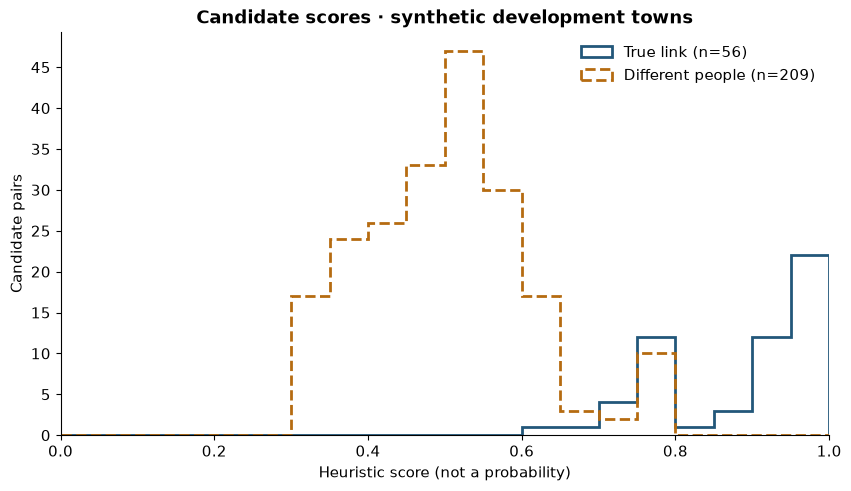

In [8]:
fig = plot_scores(pairs, development_truth)
display(fig)
plt.close(fig)

The distributions overlap: matching names are useful evidence, but shared names and missing fields prevent a perfect separation. The histogram uses development candidates only; candidates excluded during blocking do not appear here.

## 5. Visualisation exercises
### Exercise A — change the threshold

Run the curve below, then compare thresholds 0.55, 0.75 and 0.86. How many extra correct links and false links are accepted? Why are recall and coverage different? Keep the margin rule fixed. All tuning uses development labels.

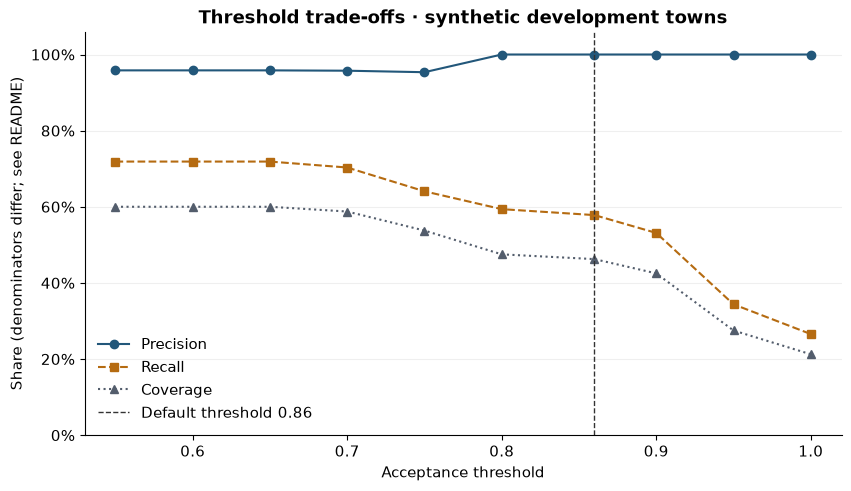

,threshold,accepted,correct,false_links,precision,recall,coverage
0,0.55,48,46,2,0.9583,0.7188,0.6000
4,0.75,43,41,2,0.9535,0.6406,0.5375
6,0.86,37,37,0,1.0000,0.5781,0.4625


In [9]:
sweep = threshold_sweep(records, pairs, development_truth)
fig = plot_thresholds(sweep)
display(fig)
plt.close(fig)
display(pd.DataFrame(sweep).loc[lambda x: x["threshold"].isin([.55, .75, .86]),
                               ["threshold", "accepted", "correct", "false_links", "precision", "recall", "coverage"]].round(4))

At 0.55, the development set accepts 48 links: 46 correct and 2 false. At 0.86, it accepts 37, all correct. The lower threshold adds 9 correct links and 2 mistakes. These thresholds are illustrative choices, not an optimisation claim. Once thresholds are changed after seeing the held-out result, that set is no longer untouched test evidence.

### Exercise B — compare the decision mix

Inspect the count chart. Recreate it using shares instead of counts, and explain whether that changes the comparison when every town has 20 baseline people. Which town would require the most manual review? Why is the accepted-link share not an estimate of true administrative continuity?

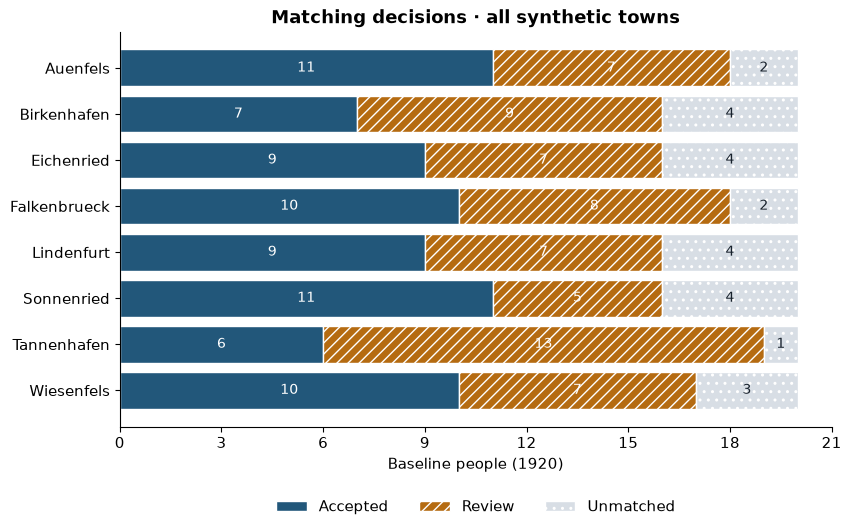

status,accepted,review,unmatched
town (percent of baseline people),,,
Auenfels,55.0,35.0,10.0
Birkenhafen,35.0,45.0,20.0
Eichenried,45.0,35.0,20.0
Falkenbrueck,50.0,40.0,10.0
Lindenfurt,45.0,35.0,20.0
Sonnenried,55.0,25.0,20.0
Tannenhafen,30.0,65.0,5.0
Wiesenfels,50.0,35.0,15.0


In [10]:
fig = plot_decisions(decisions)
display(fig)
plt.close(fig)
counts = pd.crosstab(match_frame["town"], match_frame["status"]).reindex(columns=["accepted", "review", "unmatched"], fill_value=0)
shares = counts.div(counts.sum(axis=1), axis=0)
display((100 * shares).round(1).rename_axis("town (percent of baseline people)"))

Tannenhafen has 13 review cases out of 20 baseline people, the largest review workload. The share chart preserves this ranking because denominators are equal. True continuity is 16/20 = 80% in each synthetic town; variation in accepted links reflects the matching procedure and available evidence.

### Exercise C — recover movers by widening the block

The baseline only compares records within the same town. Repeat candidate generation across **development towns only**. Compare candidate volume, candidate recall and accepted-link recall. Explain why recovering candidates does not guarantee correct accepted links, and why a large real dataset needs better blocking than all-pairs comparison.

,candidates,candidate_recall,accepted,correct,precision,recall,coverage
block,,,,,,,
Within town,265,0.875,37,37,1.0,0.5781,0.4625
Across development towns,857,1.000,39,39,1.0,0.6094,0.4875


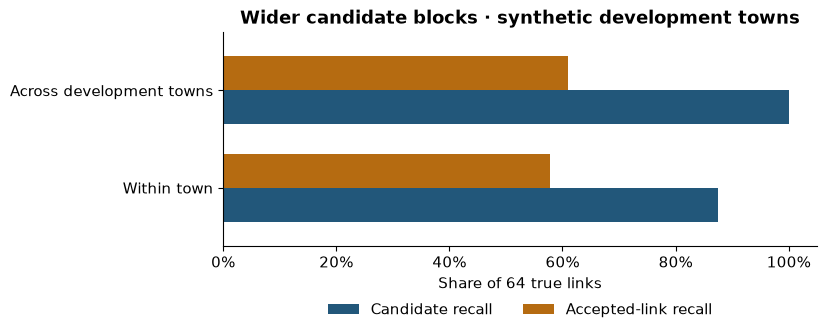

In [11]:
development_towns = {row["town"] for row in development_truth}
development_records = [row for row in records if row["town"] in development_towns]
local_pairs = candidates(development_records)
wide_pairs = candidates(development_records, same_town=False)
blocking_results = []
for name, experiment_pairs in [("Within town", local_pairs), ("Across development towns", wide_pairs)]:
    experiment_matches = find_matches(development_records, experiment_pairs)
    metrics = evaluate(experiment_matches, experiment_pairs, development_truth)
    blocking_results.append(dict(block=name, candidates=len(experiment_pairs), **metrics))
blocking = pd.DataFrame(blocking_results).set_index("block")
display(blocking[["candidates", "candidate_recall", "accepted", "correct", "precision", "recall", "coverage"]].round(4))
ax = blocking[["candidate_recall", "recall"]].rename(columns={"candidate_recall": "Candidate recall", "recall": "Accepted-link recall"}).plot.barh(
    color=["#22577A", "#B56B11"], figsize=(8.4, 3.6), xlim=(0, 1.05), width=.7)
from matplotlib.ticker import PercentFormatter
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set(title="Wider candidate blocks · synthetic development towns", xlabel="Share of 64 true links", ylabel="")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, -.20), ncol=2)
ax.figure.tight_layout()
display(ax.figure)
plt.close(ax.figure)

Allowing across-town comparisons raises candidate recall to 100%, but only 39 of 64 true links are accepted (60.94% recall), versus 37 under within-town blocking. Missing evidence, lookalikes and conservative margins still matter. Widening blocks increases comparison cost and opportunities for false matches.

## Checks and next steps

`python -m unittest -v` checks source-line traceability, known totals, metric denominators, migrant losses, missingness, rejected records, duplicate-ID/pair rejection, one-to-one assignments, unresolved ties, order independence and deterministic generation. `python run.py` writes inspectable CSVs, metric JSON and three PNGs.

This example assumes one record per person per year, two known source layouts and a small finite population. Real work would require validating extraction against page images, broader name conventions, duplicate handling, representative human labels and calibrated match rules. No causal or historical inference is made here.